In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv("dataset.csv")

In [3]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
data.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

#Handle Missing values

In [5]:
categorical_cols=data.select_dtypes(include=["object"]).columns
numerical_cols=data.select_dtypes(include=["float64"]).columns

In [6]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
data[numerical_cols]=num_imp.fit_transform(data[numerical_cols])
cat_imp=SimpleImputer(strategy="most_frequent")
data[categorical_cols]=cat_imp.fit_transform(data[categorical_cols])

In [7]:
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

#EDA(explorartory data analysis):

Text(0.5, 1.0, 'classes/variation in output')

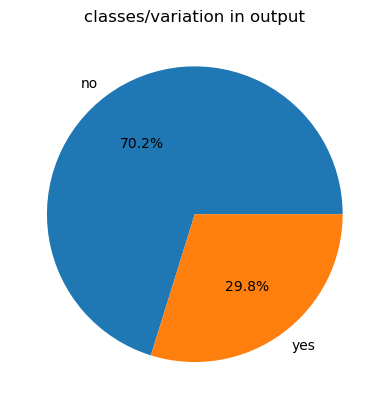

In [8]:
#for label/output
classes_counts=data["Loan_Approved"].value_counts()
plt.pie(classes_counts,labels=["no","yes"],autopct="%1.1f%%")
plt.title("classes/variation in output")

<Axes: xlabel='Gender', ylabel='count'>

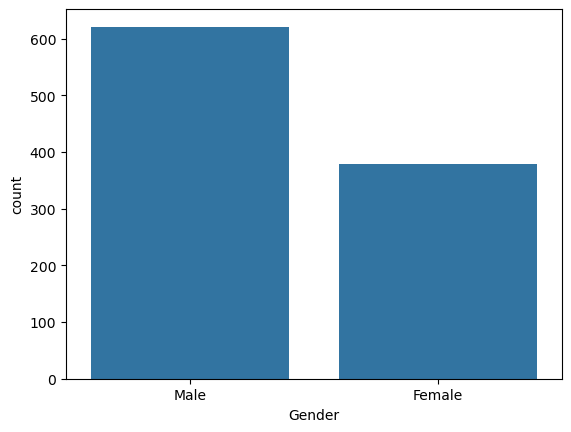

In [9]:
#see gender variation:
gen_counts=data["Gender"].value_counts()
sns.barplot(gen_counts)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

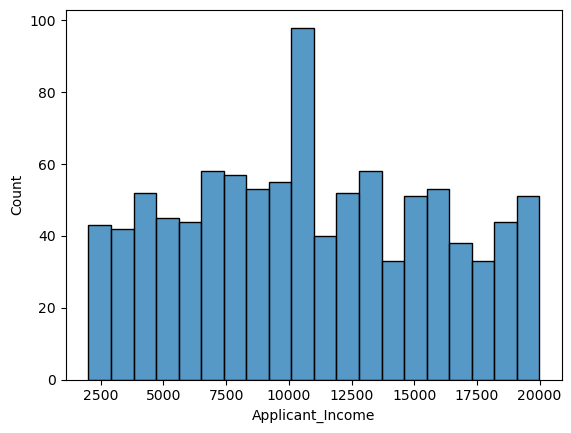

In [10]:
sns.histplot(
    data=data,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

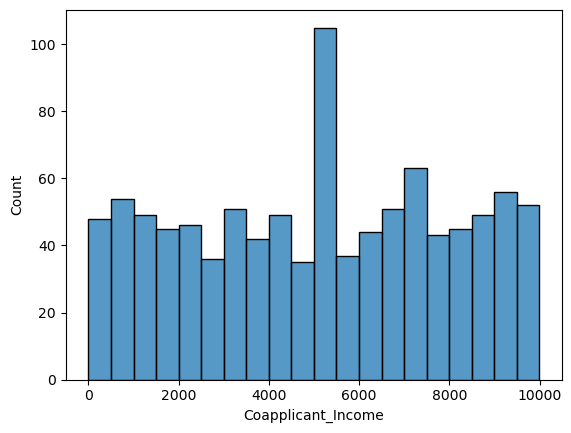

In [12]:
sns.histplot(
    data=data,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

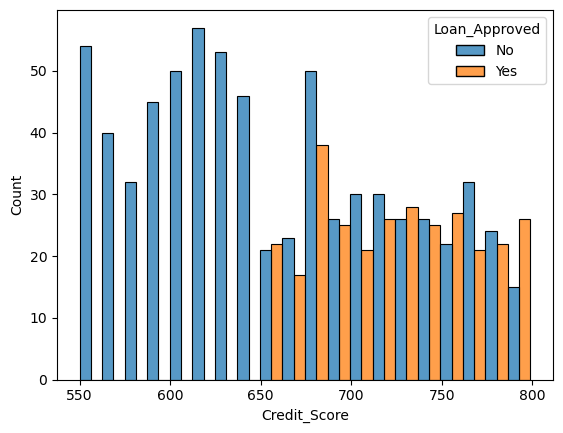

In [13]:
sns.histplot(
    data=data,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [16]:
#remove applicant id we have no need
data=data.drop("Applicant_ID",axis=1)

In [17]:
data.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
data["Education_Level"]=le.fit_transform(data["Education_Level"])
data["Loan_Approved"]=le.fit_transform(data["Loan_Approved"])

In [19]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [22]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(data[cols])
encoded_data=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=data.index)
data=pd.concat([data.drop(columns=cols),encoded_data],axis=1)

#Feature scaling

In [24]:
X=data.drop("Loan_Approved",axis=1)
Y=data["Loan_Approved"]

In [25]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [30]:
#train model:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
model=LogisticRegression()
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
print("precision score is: ",precision_score(Y_test,y_pred))
print("accuracy is: ",accuracy_score(Y_test,y_pred))
print("recall score is: ",recall_score(Y_test,y_pred))
print("F1 score is : ",f1_score(Y_test,y_pred))

precision score is:  0.8518518518518519
accuracy is:  0.885
recall score is:  0.7540983606557377
F1 score is :  0.8


In [31]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,Y_train)
y_pred1=knn_model.predict(X_test_scaled)
print("precision score is: ",precision_score(Y_test,y_pred1))
print("accuracy is: ",accuracy_score(Y_test,y_pred1))
print("recall score is: ",recall_score(Y_test,y_pred1))
print("F1 score is : ",f1_score(Y_test,y_pred1))

precision score is:  0.6086956521739131
accuracy is:  0.745
recall score is:  0.45901639344262296
F1 score is :  0.5233644859813084


#Now we can try to improve our model:

In [41]:
data["DTI_Ratio_sq"]=data["DTI_Ratio"]**2
data["Credit_Score_sq"]=data["Credit_Score"]**2
data["Applicant_Income_log"]=np.log1p(data["Applicant_Income"])
X=data.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio","Applicant_Income"])
Y=data["Loan_Approved"]

#spliting the data:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

#scaling the data:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [42]:
#1st logistic regression model:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
model=LogisticRegression()
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
print("precision score is: ",precision_score(Y_test,y_pred))
print("accuracy is: ",accuracy_score(Y_test,y_pred))
print("recall score is: ",recall_score(Y_test,y_pred))
print("F1 score is : ",f1_score(Y_test,y_pred))

precision score is:  0.8679245283018868
accuracy is:  0.89
recall score is:  0.7540983606557377
F1 score is :  0.8070175438596491


In [43]:
#knn model:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,Y_train)
y_pred1=knn_model.predict(X_test_scaled)
print("precision score is: ",precision_score(Y_test,y_pred1))
print("accuracy is: ",accuracy_score(Y_test,y_pred1))
print("recall score is: ",recall_score(Y_test,y_pred1))
print("F1 score is : ",f1_score(Y_test,y_pred1))

precision score is:  0.6274509803921569
accuracy is:  0.76
recall score is:  0.5245901639344263
F1 score is :  0.5714285714285714


In [44]:
#after improving we get the better result:

In [46]:
#check the result for one output:
# Create a new customer's data
new_customer = pd.DataFrame({
    "Applicant_Income_log":[6000],
    "Coapplicant_Income":[2500],
    "Age":[30],
    "Dependents":[2],
    "Credit_Score_sq":[750],
    "Existing_Loans":[1],
    "DTI_Ratio_sq":[35],
    "Savings":[50000],
    "Collateral_Value":[800000],
    "Loan_Amount":[400000],
    "Loan_Term":[240],
    "Education_Level": [1],
    "Employment_Status":["Salaried"],
    "Marital_Status":["Married"],
    "Loan_Purpose":["Home"],
    "Property_Area":["Urban"],
    "Gender":["Male"],
    "Employer_Category":["Private"]
})

# One-Hot Encode categorical columns
encoded = ohe.transform(new_customer[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols)
)

# Remove original categorical columns
new_customer = new_customer.drop(columns=cols)

# Combine numerical and encoded features
new_customer = pd.concat(
    [new_customer.reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

# Make sure column order matches the training data
new_customer = new_customer[X_train.columns]

# Scale the data
new_customer_scaled = scaler.transform(new_customer)

# Predict
prediction = model.predict(new_customer_scaled)

# Display result
if prediction[0] == 1:
    print("✅ Loan Approved")
else:
    print("❌ Loan Rejected")

✅ Loan Approved
